In [2]:
from datetime import datetime
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch


In [3]:
def _find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "outputs").exists() and (candidate / "experiments").exists():
            return candidate
    raise FileNotFoundError(f"Could not find repo root from: {start}")


REPO_ROOT = _find_repo_root(Path.cwd())
for path in (REPO_ROOT / "experiments", REPO_ROOT / "guidance", REPO_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import robosuite
robosuite_pkg_root = REPO_ROOT / "robosuite" / "robosuite"
robosuite.__file__ = str(robosuite_pkg_root / "__init__.py")
robosuite.__path__ = [str(robosuite_pkg_root)]
from robosuite.environments.base import make as robosuite_make
from robosuite.environments.manipulation.pick_place import PickPlaceCan

if not hasattr(robosuite, "make"):
    robosuite.make = robosuite_make

from robomimic.utils import torch_utils as TorchUtils
from diffusion_comparison import (
    DEFAULT_WORLD_MODEL_RUN_PATH,
    MethodSpec,
    _ensure_dir,
    _extract_current_obs_dict,
    _rotation_6d_to_rzz_torch,
    _run_rollout_episode,
    _save_rollout_artifacts,
    _summarize_rollout,
    load_policy_and_env,
)
from world_model_utils import build_state_from_obs_dict, load_init_state_json, load_model_for_eval


INIT_STATE_DIR = REPO_ROOT / "outputs/can_rollouts/snr/n16h300r60g1bYfYv1"
INIT_STATE_PATH = INIT_STATE_DIR / "init_state.json"
SEED = 7
GUIDANCE_SCALE = 25.0
HORIZON = 300
GUIDANCE_ROLLOUT_STEPS = 8
POLICY_CKPT_PATH = Path("/scratch/gilbreth/zoellner/diffusion_runs/can_mh_lowdim/20260209180642/models/model_epoch_2000.pth")

if not INIT_STATE_PATH.exists():
    raise FileNotFoundError(f"Missing init state: {INIT_STATE_PATH}")
if not POLICY_CKPT_PATH.exists():
    raise FileNotFoundError(f"Missing policy checkpoint: {POLICY_CKPT_PATH}")


def _make_eef_guidance_helpers(predictor: torch.nn.Module, stats: dict, device: str, rollout_steps: int = 8):
    state_mean = torch.tensor(stats["state_mean"], device=device, dtype=torch.float32).unsqueeze(0)
    state_std = torch.tensor(stats["state_std"], device=device, dtype=torch.float32).unsqueeze(0)
    action_mean = torch.tensor(stats["action_mean"], device=device, dtype=torch.float32).unsqueeze(0)
    action_std = torch.tensor(stats["action_std"], device=device, dtype=torch.float32).unsqueeze(0)
    delta_mean = torch.tensor(stats["delta_mean"], device=device, dtype=torch.float32).unsqueeze(0)
    delta_std = torch.tensor(stats["delta_std"], device=device, dtype=torch.float32).unsqueeze(0)

    def rollout_score_from_state(state_now: np.ndarray, actions: torch.Tensor) -> torch.Tensor:
        state = torch.as_tensor(state_now, device=device, dtype=torch.float32).unsqueeze(0)
        state = state.expand(actions.shape[0], -1).contiguous()

        horizon = min(int(rollout_steps), int(actions.shape[1]))
        eef_rzz_traj = []

        for step_idx in range(horizon):
            action_t = actions[:, step_idx, :]
            state_n = (state - state_mean) / state_std
            action_n = (action_t - action_mean) / action_std
            delta_n = predictor(state_n, action_n)
            delta = delta_n * delta_std + delta_mean
            state = state + delta
            eef_rzz_traj.append(_rotation_6d_to_rzz_torch(state[:, 21:27]))

        eef_rzz_stack = torch.stack(eef_rzz_traj, dim=1)
        return -eef_rzz_stack.mean(dim=1)

    def guidance_function(obs_dict: dict, actions: torch.Tensor) -> torch.Tensor:
        current_obs = _extract_current_obs_dict(obs_dict)
        state_now = build_state_from_obs_dict(current_obs)
        objective = rollout_score_from_state(state_now, actions).mean()
        return torch.autograd.grad(objective, actions, retain_graph=False, create_graph=False)[0]

    return rollout_score_from_state, guidance_function


def _sanitize_action(action: np.ndarray) -> np.ndarray:
    action = np.asarray(action, dtype=np.float32)
    action = np.nan_to_num(action, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(action, -1.0, 1.0)


print(f"repo root: {REPO_ROOT}")
print(f"init state: {INIT_STATE_PATH}")
print(f"policy checkpoint: {POLICY_CKPT_PATH}")

[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /home/zoellner/src/guided-diffusion/robosuite/robosuite/scripts/setup_macros.py (macros.py:55)
/home/zoellner/.conda/envs/guided_diffusion/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo root: /home/zoellner/src/guided-diffusion
init state: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/snr/n16h300r60g1bYfYv1/init_state.json
policy checkpoint: /scratch/gilbreth/zoellner/diffusion_runs/can_mh_lowdim/20260209180642/models/model_epoch_2000.pth


In [ ]:
device = TorchUtils.get_torch_device(try_to_use_cuda=True)
env, policy, _ = load_policy_and_env(str(POLICY_CKPT_PATH), device=device, record_video=True)
predictor, stats, _, _ = load_model_for_eval(
    model_or_run_path=DEFAULT_WORLD_MODEL_RUN_PATH,
    predictor_kind="learned",
    device=device,
    load_val_trajectories=False,
)
score_fn, guidance_fn = _make_eef_guidance_helpers(
    predictor=predictor,
    stats=stats,
    device=device,
    rollout_steps=GUIDANCE_ROLLOUT_STEPS,
)

init_state = load_init_state_json(str(INIT_STATE_PATH))
print(f"loaded env + policy on device: {device}")
print(f"init state keys: {list(init_state.keys())[:5]}")


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_quat', 'robot0_eef_pos', 'robot0_gripper_qpos', 'object']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


In [5]:
GUIDANCE_SCALE = 50
method = MethodSpec(
    slug=f"dp_guidance_l{int(GUIDANCE_SCALE)}",
    label=f"Guidance λ={int(GUIDANCE_SCALE)}",
    kind="guided",
    guidance_scale=GUIDANCE_SCALE,
)

# Keep output directory creation in rollout cell.
run_root_base = REPO_ROOT / "outputs/can_rollouts/notebook_junk/single_rollouts"
run_id = f"{INIT_STATE_DIR.name}_{method.slug}_seed{SEED}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_output_path = _ensure_dir(run_root_base / run_id)
video_path = run_output_path / "video.mp4"

rollout = _run_rollout_episode(
    env=env,
    policy=policy,
    init_state=init_state,
    seed=SEED,
    horizon=HORIZON,
    video_path=video_path,
    camera_names=["frontview"],
    video_skip=1,
    method=method,
    score_fn=score_fn,
    guidance_fn=guidance_fn,
)
summary = _summarize_rollout(method, INIT_STATE_DIR, SEED, rollout, run_output_path)
_save_rollout_artifacts(run_output_path, rollout, summary)

print(f"output dir: {run_output_path}")
print(f"video path: {video_path}")
print(json.dumps(summary, indent=2))

  0%|          | 0/300 [00:00<?, ?it/s]

ObservationKeyToModalityDict: robot0_joint_pos not found, adding robot0_joint_pos to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: robot0_joint_pos_cos not found, adding robot0_joint_pos_cos to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: robot0_joint_pos_sin not found, adding robot0_joint_pos_sin to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: robot0_joint_vel not found, adding robot0_joint_vel to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: robot0_eef_quat_site not found, adding robot0_eef_quat_site to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: robot0_gripper_qvel not found, adding robot0_gripper_qvel to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: lang_emb not found, adding lang_emb to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: timesteps not found, adding timesteps to mapping with assumed low_dim modality!
Observat

AssertionError: 

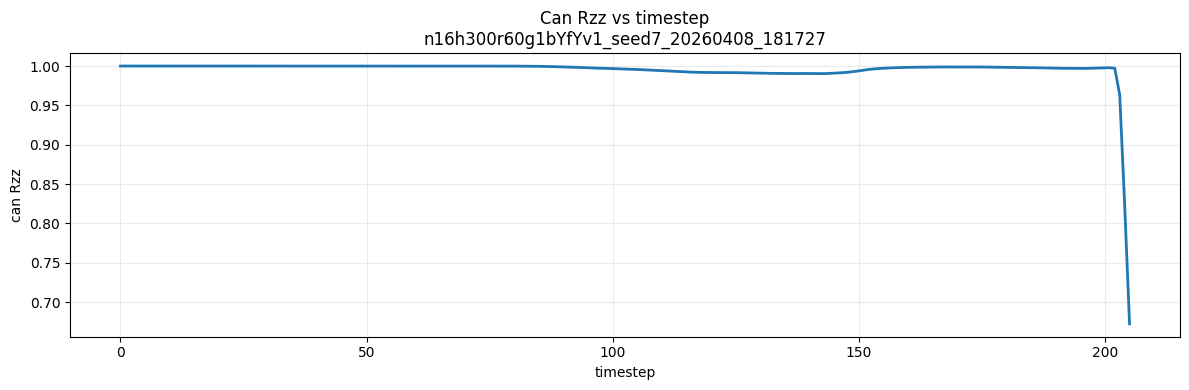

loaded: /home/zoellner/src/guided-diffusion/outputs/can_rollouts/notebook_junk/single_rollouts/n16h300r60g1bYfYv1_seed7_20260408_181727/rollout_numeric.npz
len=206 | min=0.672320 | mean=0.994816 | max=1.000000


In [13]:
run_output_root = run_output_path if "run_output_path" in globals() else None
if run_output_root is None:
    base_dir = REPO_ROOT / "outputs/can_rollouts/notebook_junk/single_rollouts"
    candidates = sorted([p for p in base_dir.iterdir() if p.is_dir()])
    if not candidates:
        raise FileNotFoundError(f"No rollout outputs found under: {base_dir}")
    run_output_root = candidates[-1]

npz_path = run_output_root / "rollout_numeric.npz"
if not npz_path.exists():
    raise FileNotFoundError(f"Missing rollout_numeric.npz: {npz_path}")

data = np.load(npz_path)
rzz = np.asarray(data["rzz_mujoco"], dtype=np.float32)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(np.arange(len(rzz)), rzz, color="#1f77b4", lw=2.0)
ax.set_title(f"Can Rzz vs timestep\n{run_output_root.name}")
ax.set_xlabel("timestep")
ax.set_ylabel("can Rzz")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"loaded: {npz_path}")
print(f"len={len(rzz)} | min={rzz.min():.6f} | mean={rzz.mean():.6f} | max={rzz.max():.6f}")

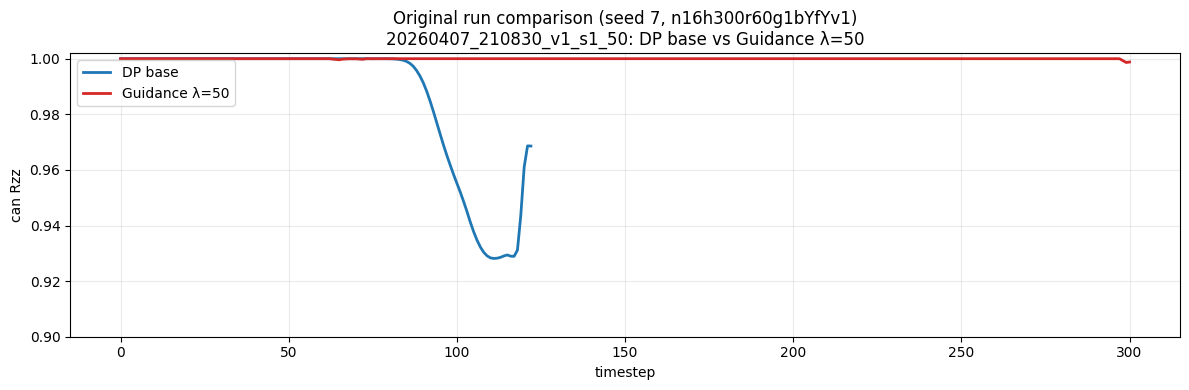

run root: /scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/20260407_210830_v1_s1_50
DP base | len=123 | min=0.928156 | mean=0.986516 | max=1.000000
Guidance λ=50 | len=301 | min=0.998635 | mean=0.999984 | max=1.000000


In [14]:
# Baseline comparison from original 50-seed run: DP base vs Guidance λ=50

comparison_run_root = Path("/scratch/gilbreth/zoellner/diffusion_rollouts/can_rollouts/comparison/20260407_210830_v1_s1_50")
env_name = INIT_STATE_DIR.name
seed = SEED

method_to_label = {
    "dp_base": "DP base",
    "dp_guidance_l50": "Guidance λ=50",
}
method_to_color = {
    "dp_base": "#1f77b4",
    "dp_guidance_l50": "#d62728",
}

seed_to_rzz = {}
for method_slug in ["dp_base", "dp_guidance_l50"]:
    npz_path = comparison_run_root / method_slug / f"{env_name}__seed_{seed:02d}" / "rollout_numeric.npz"
    if not npz_path.exists():
        raise FileNotFoundError(f"Missing rollout file: {npz_path}")
    data = np.load(npz_path)
    seed_to_rzz[method_slug] = np.asarray(data["rzz_mujoco"], dtype=np.float32)

fig, ax = plt.subplots(figsize=(12, 4))
for method_slug in ["dp_base", "dp_guidance_l50"]:
    rzz = seed_to_rzz[method_slug]
    ax.plot(
        np.arange(len(rzz)),
        rzz,
        lw=2.0,
        color=method_to_color[method_slug],
        label=method_to_label[method_slug],
    )

ax.set_title(
    f"Original run comparison (seed {seed}, {env_name})\n"
    f"{comparison_run_root.name}: DP base vs Guidance λ=50"
)
ax.set_xlabel("timestep")
ax.set_ylabel("can Rzz")
ax.set_ylim(0.9, 1.002)
ax.grid(alpha=0.25)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

print(f"run root: {comparison_run_root}")
for method_slug in ["dp_base", "dp_guidance_l50"]:
    rzz = seed_to_rzz[method_slug]
    print(f"{method_to_label[method_slug]} | len={len(rzz)} | min={rzz.min():.6f} | mean={rzz.mean():.6f} | max={rzz.max():.6f}")